|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Regularization<h1>|
|<h2>Lecture:</h2>|<h1><b>Dropout example 2<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

In [2]:
# import dataset
import pandas as pd
iris = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv')

# convert from pandas dataframe to tensor
data = torch.tensor( iris[iris.columns[0:4]].values ).float()

# transform species to number
labels = torch.zeros(len(data), dtype=torch.long)
# labels[iris.species=='setosa'] = 0 # don't need!
labels[iris.species=='versicolor'] = 1
labels[iris.species=='virginica'] = 2

# Separate the data into DataLoaders

In [3]:
# use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(data, labels, test_size=.2)


# then convert them into PyTorch Datasets (note: already converted to tensors)
train_data = torch.utils.data.TensorDataset(train_data,train_labels)
test_data  = torch.utils.data.TensorDataset(test_data,test_labels)


# finally, translate into dataloader objects
batchsize    = 16
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0]) # how big should these batches be??

# Create the model and a training regimen

In [4]:
class theModelClass(nn.Module):
  def __init__(self,dropoutRate):
    super().__init__()

    ### layers
    self.nUnit = 256
    self.input  = nn.Linear( 4,self.nUnit)
    self.nLayers = 3
    self.hidden = nn.ModuleDict()
    for n in range(self.nLayers):
      self.hidden[f'hidden{n}'] = nn.Linear(self.nUnit,self.nUnit)
    self.output = nn.Linear(self.nUnit, 3)
    # parameters
    self.dr = dropoutRate

  # forward pass
  def forward(self,x):

    # input
    x = self.input(x)
    x = F.relu( x )
    x = F.dropout(x,p=self.dr,training=self.training) # switch dropout off during .eval()

    # hidden
    for n in range(self.nLayers):
      x = self.hidden[f'hidden{n}'](x)
      x = F.relu( x )
      x = F.dropout(x,p=self.dr,training=self.training)

    # output
    x = self.output(x)
    return x

In [5]:
# test the model
tmpnet = theModelClass(.25)

# run some random data through
tmpdata = torch.randn((10,4))
yhat = tmpnet(tmpdata)
yhat

tensor([[-0.0393, -0.0486,  0.0104],
        [-0.0623, -0.0686,  0.0366],
        [-0.0730, -0.0707, -0.0168],
        [-0.1138, -0.0765, -0.0409],
        [-0.1267,  0.0021,  0.0156],
        [-0.0907, -0.0702,  0.0370],
        [-0.0938, -0.0353, -0.0279],
        [-0.0910, -0.0865,  0.0040],
        [-0.0809, -0.0394,  0.0116],
        [-0.0518, -0.0725, -0.0171]], grad_fn=<AddmmBackward0>)

In [6]:
# a function that creates the ANN model

def createANewModel(dropoutrate):

  # grab an instance of the model class
  ANNiris = theModelClass(dropoutrate)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.SGD(ANNiris.parameters(),lr=.005)

  return ANNiris,lossfun,optimizer

In [7]:
# train the model

# global parameter
numepochs = 1000

def trainTheModel():

  # initialize accuracies as empties (not storing losses here)
  trainAcc = []
  testAcc  = []

  # loop over epochs
  for epochi in range(numepochs):

    # switch learning on
    ANNiris.train()

    # loop over training data batches
    batchAcc = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = ANNiris(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # compute training accuracy just for this batch
      batchAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1) == y).float()).item() )
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # test accuracy
    ANNiris.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    predlabels = torch.argmax( ANNiris(X),axis=1 )
    testAcc.append( 100*torch.mean((predlabels == y).float()).item() )

  # function output
  return trainAcc,testAcc


# Now for the real work! ;)

In [8]:
# create a model
dropoutrate = .0
ANNiris,lossfun,optimizer = createANewModel(dropoutrate)

# train the model
trainAcc,testAcc = trainTheModel()

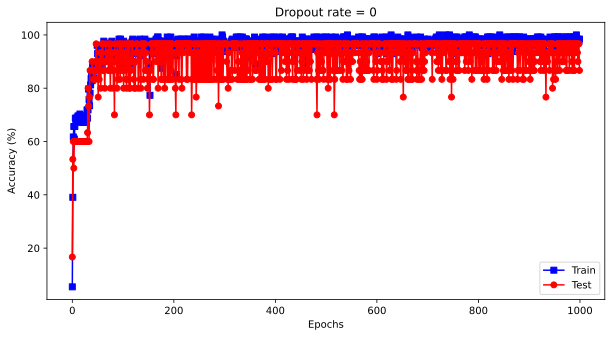

In [9]:
# plot the results
fig = plt.figure(figsize=(10,5))

plt.plot(trainAcc,'bs-')
plt.plot(testAcc,'ro-')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(['Train','Test'])
plt.title('Dropout rate = %g'%dropoutrate)

plt.show()

In [10]:
# run an experiment

dropoutRates = np.arange(10)/10
results = np.zeros((len(dropoutRates),2))

for di in range(len(dropoutRates)):

  # create and train the model
  ANNiris,lossfun,optimizer = createANewModel(dropoutRates[di])
  trainAcc,testAcc = trainTheModel()

  # store accuracies
  results[di,0] = np.mean(trainAcc[-50:])
  results[di,1] = np.mean(testAcc[-50:])


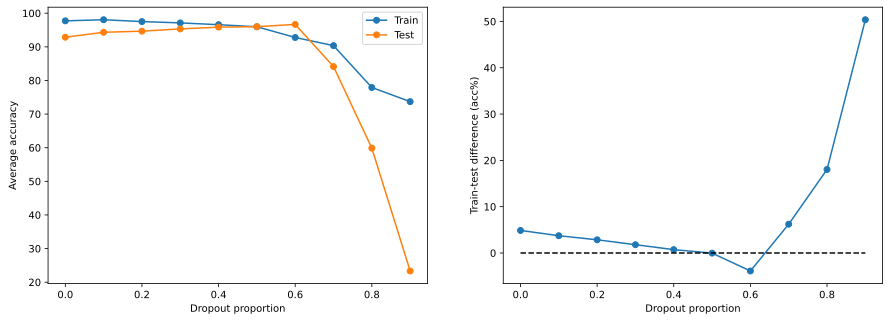

In [11]:
# plot the experiment results
fig,ax = plt.subplots(1,2,figsize=(15,5))

ax[0].plot(dropoutRates,results,'o-')
ax[0].set_xlabel('Dropout proportion')
ax[0].set_ylabel('Average accuracy')
ax[0].legend(['Train','Test'])

ax[1].plot(dropoutRates,-np.diff(results,axis=1),'o-')
ax[1].plot([0,.9],[0,0],'k--')
ax[1].set_xlabel('Dropout proportion')
ax[1].set_ylabel('Train-test difference (acc%)')

plt.show()

# Additional explorations

In [ ]:
# 1) Remove the ReLU nonlinearity from the network. Does that change the effect of dropout proportion on performance?
#
# In general accuracy drops less with increased number of dropouts withotu ReLU layers, but follows same pattern as with ReLU,
# namely decreasing accuracy with increasing dropout ratio.
#
# 2) I mentioned that dropout doesn't necessarily improve performance for shallow models. What happens if you increase
#    the complexity of this model, for example by adding several additional (and wider) hidden layers?
#
# The average accuracy increases up to about 95% with dropout and large NN size (here: 3 layers of 256 units), compared to about 90% for smaller/shallow networks.
# Also number of training epochs were increased to 1000 to allow for proper convergence. The averagy accuracy stays in range betweeb 90% and 100% up to dropout rate if 0.75 and
# then starts to drop off more quickly.
# The explanation is in current example a trade-off between model size and data set complexity. While data-set stays same and pretty simple, larger model
# decreases accuracy later. This is due possibly lower amount of neirons needed to learn data-set pattern.